### Task 1: Import and Clean Data

a. Import relevant Python libraries for data manipulation and numerical operations:
pandas, numpy, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

b. Load the dataset into a Pandas DataFrame from a CSV file.
1. Filename: FloridaBikeRentals.csv

In [2]:
bikes = pd.read_csv('FloridaBikeRentals.csv', encoding='latin-1')

FileNotFoundError: [Errno 2] No such file or directory: 'FloridaBikeRentals.csv'

c. Inspect the data:
1. View the first few rows, shape, column names, and data types

In [ ]:
print(bikes.head(5))
print(bikes.shape)
print(bikes.columns)
print(bikes.dtypes)

         Date  Rented Bike Count  Hour  Temperature(C*)  Humidity(%)  \
0  01-12-2017                254     0             -5.2           37   
1  01-12-2017                204     1             -5.5           38   
2  01-12-2017                173     2             -6.0           39   
3  01-12-2017                107     3             -6.2           40   
4  01-12-2017                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(C*)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0            0.0  Winter  No Holiday   


2. Identify missing values and inconsistencies

In [ ]:
print(bikes.isnull().sum())

#bikes.head(5)

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(C*)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(C*)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


In [ ]:

bikes.describe()


,Rented Bike Count,Hour,Temperature(C*),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C*),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [ ]:
for col in bikes.select_dtypes(include=['object']).columns:
    print(f'\n{col}:')
    print(bikes[col].value_counts())


Date:
Date
30-11-2018    24
01-12-2017    24
02-12-2017    24
03-12-2017    24
04-12-2017    24
              ..
17-12-2017    24
18-12-2017    24
19-12-2017    24
20-12-2017    24
21-12-2017    24
Name: count, Length: 365, dtype: int64

Seasons:
Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

Holiday:
Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

Functioning Day:
Functioning Day
Yes    8465
No      295
Name: count, dtype: int64


In [ ]:
# Create a datetime string by combining Date and Hour
bikes['datetime_str'] = bikes['Date'].astype(str) + ' ' + bikes['Hour'].astype(str) + ':00:00'

# Convert to datetime
bikes['DateTime'] = pd.to_datetime(bikes['datetime_str'], format='%d-%m-%Y %H:%M:%S', errors='coerce')

# Drop the temporary column
bikes = bikes.drop('datetime_str', axis=1)

        We converted the initial Date feature to be a datetime type with the Hour feature added to it. We decided it would be beneficial for the data and future model to combine these feature
        
        We noted that the maximum value for the rainfall feature was 33mm, which is abnormally high for any given hour. We also noted that an hour of 0* humidity was very sketchy. There are also less data on the Winter and Autumn seasons which is something to keep an eye on.      

d. Handle missing values and data inconsistencies:
1. Report missing values and suggest appropriate handling techniques (e.g., fill with mean, drop rows, etc.)

        We do not see any missing values in the data. If there was, we would decide on method of handling depending on the feature.

2. Check for duplicate records and remove them if necessary

In [ ]:
bikes.duplicated().sum()

np.int64(0)

        There are no duplicates in the dataset

e. Comment on data types and suggest optimizations for memory efficiency.
1. Focus on columns such as Temperature, Humidity(%), Wind speed (m/s)

In [ ]:
bikes.dtypes

Date                                 object
Rented Bike Count                     int64
Hour                                  int64
Temperature(C*)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(C*)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                              object
Holiday                              object
Functioning Day                      object
DateTime                     datetime64[ns]
dtype: object

        We agree that Temperature needs to be a float datatype, as there are values given that contain decimal values. We could in theory round those values to the nearest whole number, but we chose not to do that to have a higher level of specificity in our data.

        We decided to convert Humidity to uint-8 because we saw that the min value was 0 and the max was in the 90s, so we can save memory by condensing the data type

        For Wind Speed, Rainfall, Snowfall, and other float64 datatypes, we could convert to smaller float datatypes for the same reason as above

        Holiday and Functioning Day fields could be converted to boolean datatype to save space.

        Seasons could be converted to uint-8 using Label Encoding and assigning a value for winter = 0, spring = 1, summer = 2, and fall = 3 (natural order of season progression)

        Tempurature and Dew Point are the only features that contain negative values, so we could also convert the rest to unisgned datatypes for space considerations

f. Export the cleaned data to JSON format as bike_rental_cleaned.json

In [ ]:
bikes.to_json('bike_rental_cleaned')

g. Write a short report summarizing observations about the data

We gathered a few useful observations when conducting our exploratory data analysis. We started by editing the initial icons for Temperature fields to an asterisk for readability and encoding purposes. We then imported the data from a csv file into a pandas dataframe. We inspected the data types, values and basic statistical outputs for anomalies that could not happen in our universe. We noted that there was nothing impossible, but some data that was unlikely to happen. These notes included the rainfall and humidity having rather extreme mins and max's.

After that, we looked for and found no duplicates or missing values.

We then made many suggestions on data type changes that could save memory. A majority of these changes were quality of life, but the one necessary change we made was converting the Date column into a datetime, which concatenated the date feature with the hour feature. This singular datetime column will be much easier to conduct further analysis off of, as we are not having to look at two features to know when we are talking about now.

Finally, we exported this data into a json file named bike_rental_cleaned

### Task 2: Data Processing and Statistical Analysis

a. Perform transformations:
1. Multiply Temperature by 10 for standardization
2. Scale Visibility to a range between 0 and 1 using MinMax scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Store raw df
raw_df = pd.read_csv('FloridaBikeRentals.csv')

bikes['Temperature(C*)'] = bikes['Temperature(C*)'] * 10

scaler = MinMaxScaler()
bikes['Visibility (10m)'] = scaler.fit_transform(bikes[['Visibility (10m)']])

print(bikes['Temperature(C*)'].head(10))
print(bikes['Visibility (10m)'].head(10))

0   -52.0
1   -55.0
2   -60.0
3   -62.0
4   -60.0
5   -64.0
6   -66.0
7   -74.0
8   -76.0
9   -65.0
Name: Temperature(C*), dtype: float64
0    1.000000
1    1.000000
2    1.000000
3    1.000000
4    1.000000
5    1.000000
6    1.000000
7    1.000000
8    1.000000
9    0.963507
Name: Visibility (10m), dtype: float64


b. Conduct basic statistical analysis:
1. Use describe() function for key columns like Temperature, Humidity(%), Rented Bike Count
2. Compare the results with raw dataset statistics

In [ ]:
raw_df.describe()

,Rented Bike Count,Hour,Temperature(C*),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C*),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [ ]:
bikes.describe()

,Rented Bike Count,Hour,Temperature(C*),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C*),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),DateTime
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760
mean,704.602055,11.500000,128.829224,58.226256,1.724909,0.714559,4.073813,0.569111,0.148687,0.075068,2018-06-01 11:30:00
min,0.000000,0.000000,-178.000000,0.000000,0.000000,0.000000,-30.600000,0.000000,0.000000,0.000000,2017-12-01 00:00:00
25%,191.000000,5.750000,35.000000,42.000000,0.900000,0.462747,-4.700000,0.000000,0.000000,0.000000,2018-03-02 05:45:00
50%,504.500000,11.500000,137.000000,57.000000,1.500000,0.846934,5.100000,0.010000,0.000000,0.000000,2018-06-01 11:30:00
75%,1065.250000,17.250000,225.000000,74.000000,2.300000,1.000000,14.800000,0.930000,0.000000,0.000000,2018-08-31 17:15:00
max,3556.000000,23.000000,394.000000,98.000000,7.400000,1.000000,27.200000,3.520000,35.000000,8.800000,2018-11-30 23:00:00
std,644.997468,6.922582,119.448252,20.362413,1.036300,0.308312,13.060369,0.868746,1.128193,0.436746,NaN


        The major differences recorded here are the Tempurates increased by a factor of 10 and the visibility column edited to be on a scale of 0 to 1. The initial concatenation of the Date and Hour columns into DateTime is also visualized here

c. Identify columns that are not suitable for statistical analysis and recommend possible datatype changes

In [ ]:
bikes.dtypes

Date                                 object
Rented Bike Count                     int64
Hour                                  int64
Temperature(C*)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                    float64
Dew point temperature(C*)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                              object
Holiday                              object
Functioning Day                      object
DateTime                     datetime64[ns]
dtype: object

        The columns unsuitable for statistical analysis are all of the non numeric datatypes shown in the above describe call. Potential object datatype changes could be Seasons using Label Encoding, Holiday and Functioning day into boolean.

d. Export the processed data to a CSV file named bike_rental_processed.csv

In [ ]:
bikes.to_csv('bike_rental_processed.csv')

e. Prepare a short report on statistical observations and insights

        TO DO... more writing

### Task 3: Data Analysis with Pandas

a. Identify categorical and numerical variables
1. Focus on columns such as Seasons, Holiday, and Functioning Day

In [ ]:
bikes.dtypes

Date                                 object
Rented Bike Count                     int64
Hour                                  int64
Temperature(C*)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                    float64
Dew point temperature(C*)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                              object
Holiday                              object
Functioning Day                      object
DateTime                     datetime64[ns]
dtype: object

b. Perform pivoting operations on the dataset based on categorical columns:
1. Group by Seasons and calculate the average rented bike count

In [ ]:
grouped_bikes = bikes.groupby('Seasons').agg(avg_rent_ct = pd.NamedAgg(column='Rented Bike Count', aggfunc='mean'))
grouped_bikes

,avg_rent_ct
Seasons,
Autumn,819.597985
Spring,730.031250
Summer,1034.073370
Winter,225.541204


2. Analyze trends across Holiday and Functioning Day

In [ ]:
grouped_bikes = bikes.groupby('Holiday').agg(avg_rent_ct = pd.NamedAgg(column='Rented Bike Count', aggfunc='mean'))
print(grouped_bikes)

grouped_bikes = bikes.groupby('Functioning Day').agg(avg_rent_ct = pd.NamedAgg(column='Rented Bike Count', aggfunc='mean'))
print(grouped_bikes)

            avg_rent_ct
Holiday                
Holiday      499.756944
No Holiday   715.228026
                 avg_rent_ct
Functioning Day             
No                  0.000000
Yes               729.156999


        In our analysis, we noticed that on a non-holiday, there was a significant number of more bike rentals on average when compared to a non-holiday.

        We also noted that the average number of bike rentals for a functioning day across the period is ~729. This means that there are non holidays that are non functioning days that lower that average.

c. Create distribution tables:
1. Temperature and Rented Bike Count distribution by Hour
2. Seasons and Rented Bike Count distribution

d. Encode categorical variables and save data as "Rental_Bike_Data_Dummy.csv"

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Seasons (LABEL ENCODING)
bikes['Seasons_Encoded'] = label_encoder.fit_transform(bikes['Seasons'])
print(bikes['Seasons_Encoded'].value_counts())

# Holiday
bikes = pd.get_dummies(bikes, columns=['Holiday'])

# Functioning Day
bikes = pd.get_dummies(bikes, columns=['Functioning Day'])

bikes.dtypes

Seasons_Encoded
1    2208
2    2208
0    2184
3    2160
Name: count, dtype: int64


Date                                 object
Rented Bike Count                     int64
Hour                                  int64
Temperature(C*)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                    float64
Dew point temperature(C*)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                              object
DateTime                     datetime64[ns]
Seasons_Encoded                       int64
Holiday_Holiday                        bool
Holiday_No Holiday                     bool
Functioning Day_No                     bool
Functioning Day_Yes                    bool
dtype: object

### Task 4: Data Visualization

a. Import visualization libraries (matplotlib, seaborn)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

b. Select appropriate visualization techniques for the data:
1. Bar plot for average rentals by Seasons


C:\Users\colto\AppData\Local\Temp\ipykernel_34416\954198988.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_avg, x='Seasons', y='Rented Bike Count', palette='viridis')


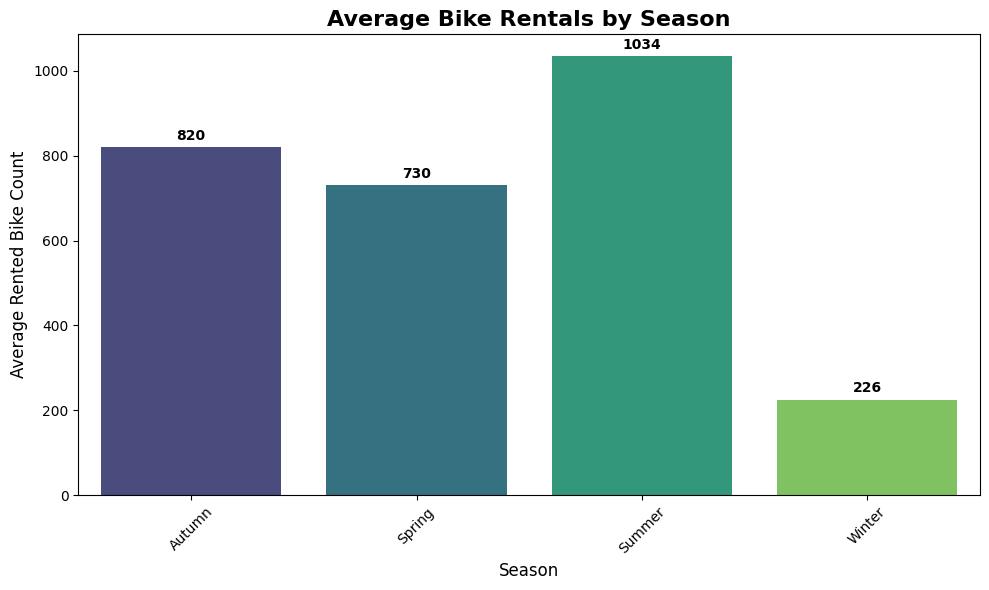

In [ ]:
# Calculate average rentals by season
season_avg = bikes.groupby('Seasons')['Rented Bike Count'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))

sns.barplot(data=season_avg, x='Seasons', y='Rented Bike Count', palette='viridis')
plt.title('Average Bike Rentals by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Rented Bike Count', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for i, v in enumerate(season_avg['Rented Bike Count']):
    plt.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


2. Line plot showing hourly rentals throughout the day

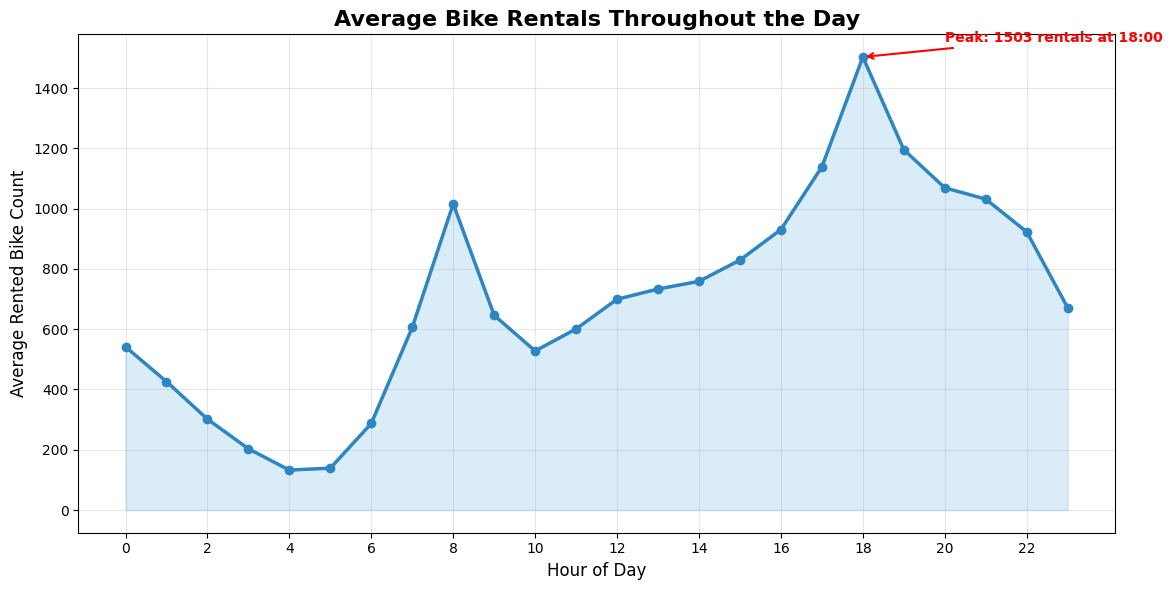

Average Bike Rentals by Hour:
 Hour  Rented Bike Count
    0         541.460274
    1         426.183562
    2         301.630137
    3         203.331507
    4         132.591781
    5         139.082192
    6         287.564384
    7         606.005479
    8        1015.701370
    9         645.983562
   10         527.821918
   11         600.852055
   12         699.441096
   13         733.246575
   14         758.824658
   15         829.186301
   16         930.621918
   17        1138.509589
   18        1502.926027
   19        1195.147945
   20        1068.964384
   21        1031.449315
   22         922.797260
   23         671.126027


In [ ]:
# Calculate average rentals by hour
hourly_avg = bikes.groupby('Hour')['Rented Bike Count'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(hourly_avg['Hour'], hourly_avg['Rented Bike Count'],
         marker='o', linewidth=2.5, markersize=6, color='#2E86C1')
plt.fill_between(hourly_avg['Hour'], hourly_avg['Rented Bike Count'], alpha=0.3, color='#85C1E9')

plt.title('Average Bike Rentals Throughout the Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Rented Bike Count', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))  # Show every 2 hours for better readability

# Add annotations for peak hours
max_hour = hourly_avg.loc[hourly_avg['Rented Bike Count'].idxmax(), 'Hour']
max_rentals = hourly_avg['Rented Bike Count'].max()
plt.annotate(f'Peak: {max_rentals:.0f} rentals at {max_hour}:00',
            xy=(max_hour, max_rentals), xytext=(max_hour+2, max_rentals+50),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Display the hourly data
print("Average Bike Rentals by Hour:")
print(hourly_avg.to_string(index=False))

3. Heatmap showing correlation among numerical variables

Numerical columns: ['Rented Bike Count', 'Hour', 'Temperature(C*)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C*)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons_Encoded']


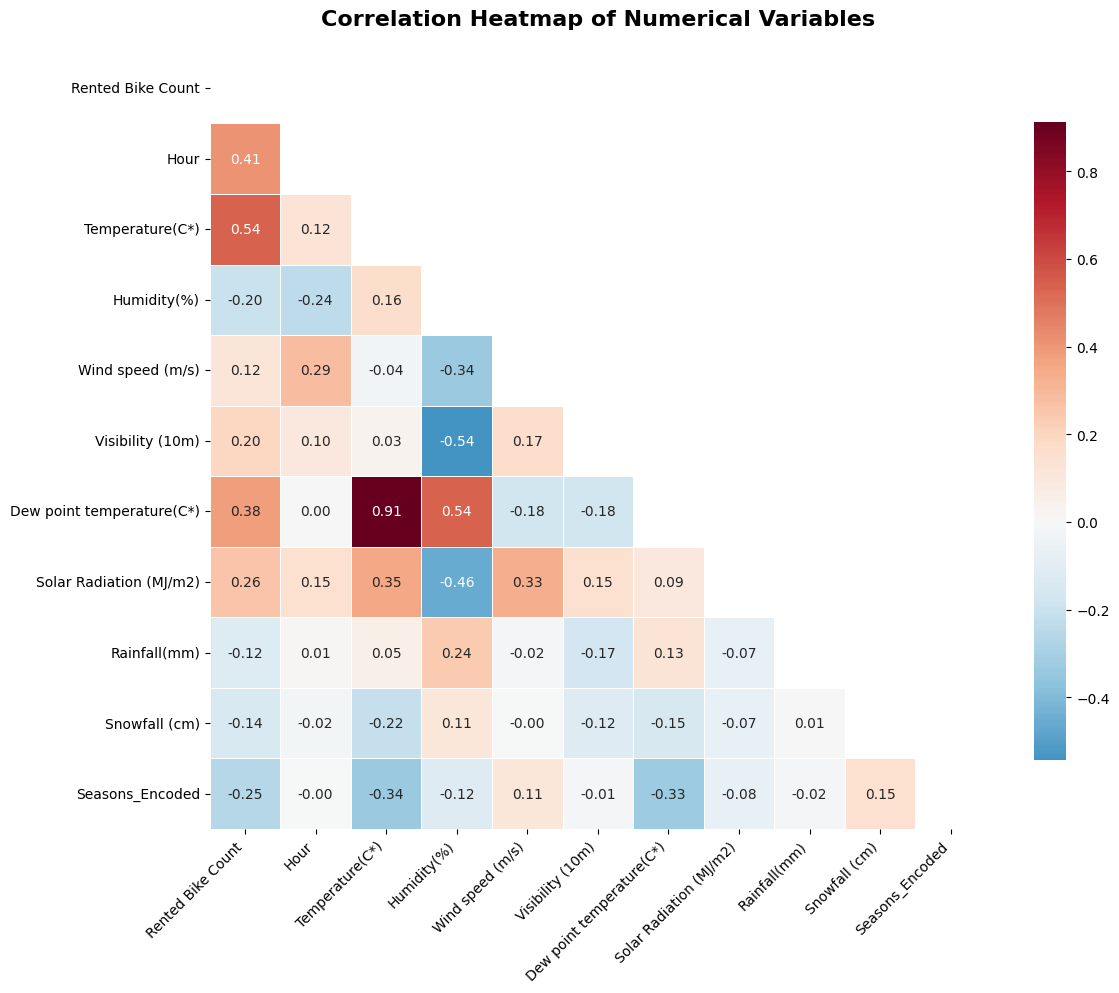


Correlation Matrix:
                           Rented Bike Count   Hour  Temperature(C*)  \
Rented Bike Count                      1.000  0.410            0.539   
Hour                                   0.410  1.000            0.124   
Temperature(C*)                        0.539  0.124            1.000   
Humidity(%)                           -0.200 -0.242            0.159   
Wind speed (m/s)                       0.121  0.285           -0.036   
Visibility (10m)                       0.199  0.099            0.035   
Dew point temperature(C*)              0.380  0.003            0.913   
Solar Radiation (MJ/m2)                0.262  0.145            0.354   
Rainfall(mm)                          -0.123  0.009            0.050   
Snowfall (cm)                         -0.142 -0.022           -0.218   
Seasons_Encoded                       -0.253 -0.000           -0.335   

                           Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
Rented Bike Count               -0.2

In [ ]:
# Select only numerical columns for correlation analysis
numerical_cols = bikes.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {list(numerical_cols)}")

# Calculate correlation matrix
correlation_matrix = bikes[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,                    # Show correlation values
            cmap='RdBu_r',                 # Red-Blue colormap (red=positive, blue=negative)
            center=0,                      # Center colormap at 0
            square=True,                   # Make cells square-shaped
            fmt='.2f',                     # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8},      # Adjust colorbar size
            linewidths=0.5,                # Add gridlines between cells
            mask=np.triu(np.ones_like(correlation_matrix, dtype=bool))) # Show only lower triangle

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display correlation matrix as a table for detailed analysis
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Find strongest correlations (excluding self-correlation)
correlations_flat = correlation_matrix.unstack()
correlations_flat = correlations_flat[correlations_flat != 1.0].dropna()
strongest_correlations = correlations_flat.abs().nlargest(10)

print("\nTop 10 Strongest Correlations:")
for (var1, var2), corr in strongest_correlations.items():
    original_corr = correlation_matrix.loc[var1, var2]
    direction = "positive" if original_corr > 0 else "negative"
    print(f"{var1} ↔ {var2}: {original_corr:.3f} ({direction})")

4. Box plot to identify outliers in Temperature and Rented Bike Count

C:\Users\colto\AppData\Local\Temp\ipykernel_34416\2808002190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bikes, y='Temperature(C*)', ax=axes[0], palette='coolwarm')
C:\Users\colto\AppData\Local\Temp\ipykernel_34416\2808002190.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bikes, y='Rented Bike Count', ax=axes[1], palette='viridis')


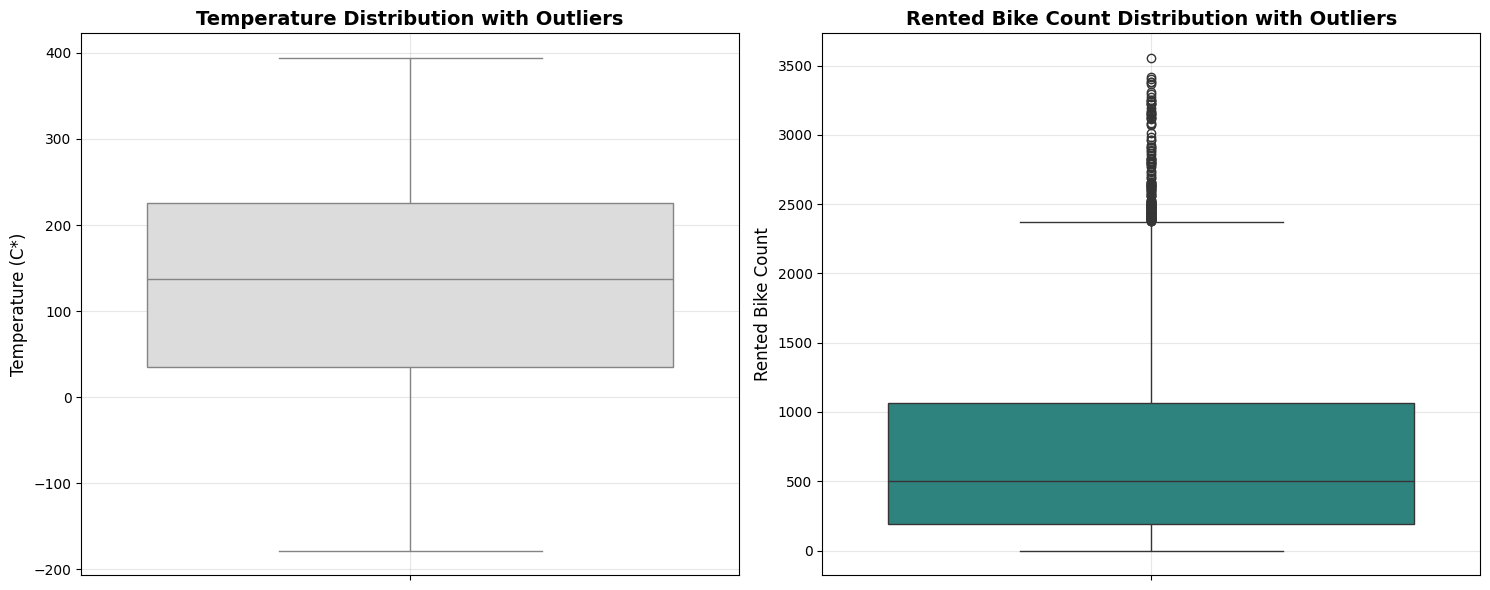

C:\Users\colto\AppData\Local\Temp\ipykernel_34416\2808002190.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data, x='Variable', y='Values', palette='Set2')


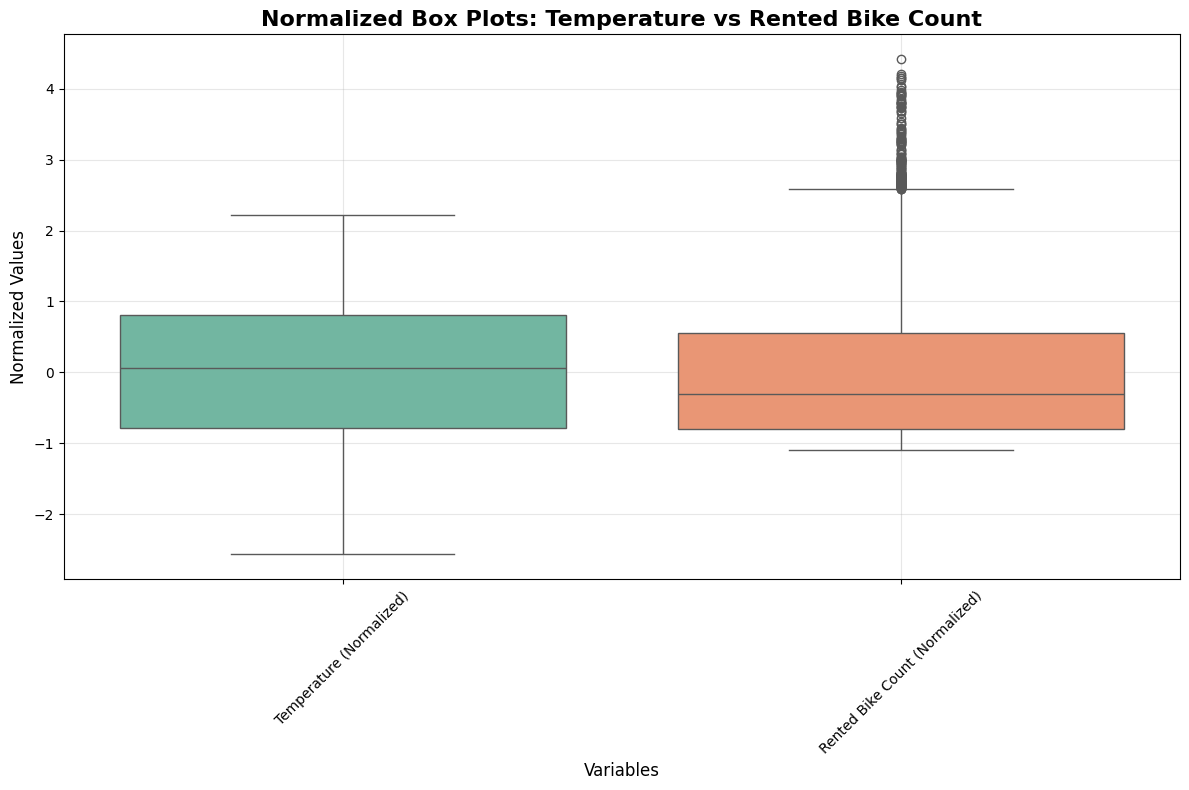

In [ ]:
# Create subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot for Temperature
sns.boxplot(data=bikes, y='Temperature(C*)', ax=axes[0], palette='coolwarm')
axes[0].set_title('Temperature Distribution with Outliers', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (C*)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Box plot for Rented Bike Count
sns.boxplot(data=bikes, y='Rented Bike Count', ax=axes[1], palette='viridis')
axes[1].set_title('Rented Bike Count Distribution with Outliers', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rented Bike Count', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Alternative: Single plot with both variables (normalized for comparison)
plt.figure(figsize=(12, 8))

# Prepare data for combined box plot
from sklearn.preprocessing import StandardScaler

# Normalize both variables for comparison
scaler = StandardScaler()
temp_normalized = scaler.fit_transform(bikes[['Temperature(C*)']])
rentals_normalized = scaler.fit_transform(bikes[['Rented Bike Count']])

# Create combined DataFrame for plotting
combined_data = pd.DataFrame({
    'Values': np.concatenate([temp_normalized.flatten(), rentals_normalized.flatten()]),
    'Variable': ['Temperature (Normalized)'] * len(temp_normalized) + ['Rented Bike Count (Normalized)'] * len(rentals_normalized)
})

sns.boxplot(data=combined_data, x='Variable', y='Values', palette='Set2')
plt.title('Normalized Box Plots: Temperature vs Rented Bike Count', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Values', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical analysis of outliers
def identify_outliers(data, column):
    """Identify outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

c. Record observations and insights from visualizations

##### Chart: Average Bike Rentals by Season
        In this chart, we saw that the largest average number of bike rentals happened in the Summer with 1034 average rentals. This was followed by Autumn with 820, Spring with 730 and finally the Winter with 226 average bike rentals. This can be explained due to the temperature associated with these seasons. It is nicest outside in the summer, so more people want to ride their bikes than in the winter

 ##### Chart: Average Bike Rentals Throughout the Day
        In this chart, we saw that there were two peaks in the data. The first being at 8am with a peak average of 1000 bikes, and the second and larger peak happening at 6pm with a peak of 1503 rentals. This can be explained by the workday and people not being free to bike during those hours.

 ##### Chart: Correlation Heatmap of Numerical Variables
        This heatmap tells us that there is a high correlation between Dew point temperature and temperature. There is also strong positive correlations with Temperature and Rented Bike Count and Dew point temperature and humidity. We also learned that there is a strong negative correlation between visibility and humidity and solar radiation and humidity.

##### Box Chart: Temperature and Rented Bike Count Distribution by Hour:
        Temperature and Rented Bike Count Distribution by Hour:
        This creates a table showing average temperature and bike rentals for each hour of the day (0-23). It reveals:
        Hourly patterns in both temperature and rentals
        Peak usage times and corresponding temperatures
        Correlation between temperature changes and rental behavior

##### Box Chart: Seasons and Rented Bike Count Distribution:
        This shows bike rental statistics grouped by season, revealing:
        Seasonal demand patterns
        Average, min, max rentals per season
        Variability in usage across different seasons


d. Save plots and observations for reporting purposes

        Plots are in the above notebook python cells. Not sure what you mean by this    